100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.7MB/s]


Device: cuda
Start plain SR training...
[plain] ep 1 step 0: loss=0.120142
[plain] ep 1 step 100: loss=0.088188
[plain] ep 1 step 200: loss=0.078928
[plain] ep 1 step 300: loss=0.078437
[plain] ep 1 step 400: loss=0.071409
[plain] epoch 1 | mean_loss=0.082582 | test_psnr=17.859 dB | bicubic=15.548 dB
[plain] ep 2 step 0: loss=0.070062
[plain] ep 2 step 100: loss=0.064135
[plain] ep 2 step 200: loss=0.063426
[plain] ep 2 step 300: loss=0.063465
[plain] ep 2 step 400: loss=0.065034
[plain] epoch 2 | mean_loss=0.065247 | test_psnr=18.359 dB | bicubic=15.548 dB
[plain] ep 3 step 0: loss=0.064579
[plain] ep 3 step 100: loss=0.063981
[plain] ep 3 step 200: loss=0.060790
[plain] ep 3 step 300: loss=0.060773
[plain] ep 3 step 400: loss=0.059378
[plain] epoch 3 | mean_loss=0.060866 | test_psnr=18.619 dB | bicubic=15.548 dB
Start drifting SR training...
[drift] ep 1 step 0: loss=0.116098 | warmup
[drift] ep 1 step 100: loss=0.089650 | warmup
[drift] ep 1 step 200: loss=0.076262 | warmup
[drift] 

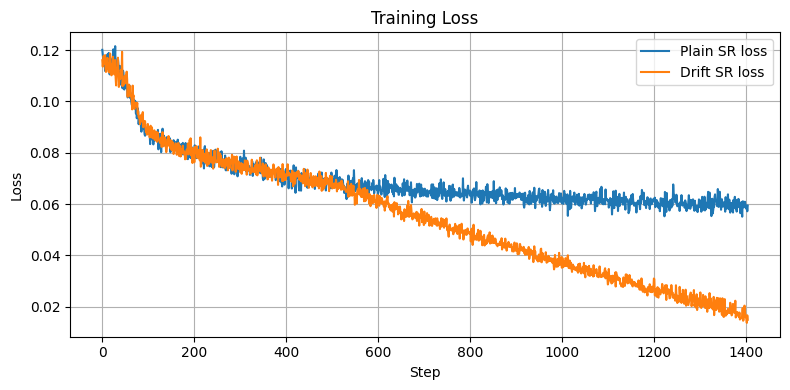

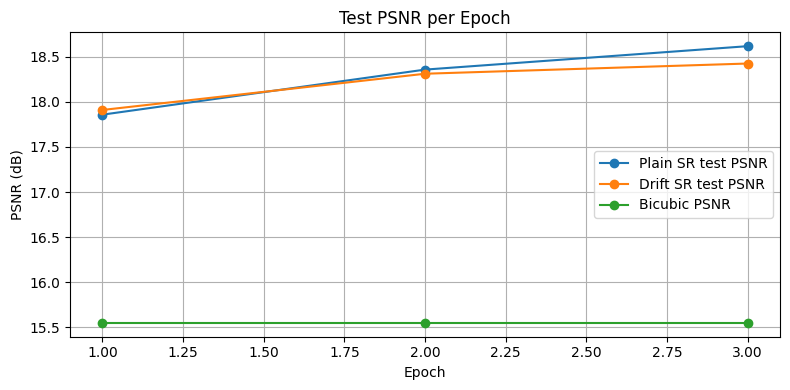

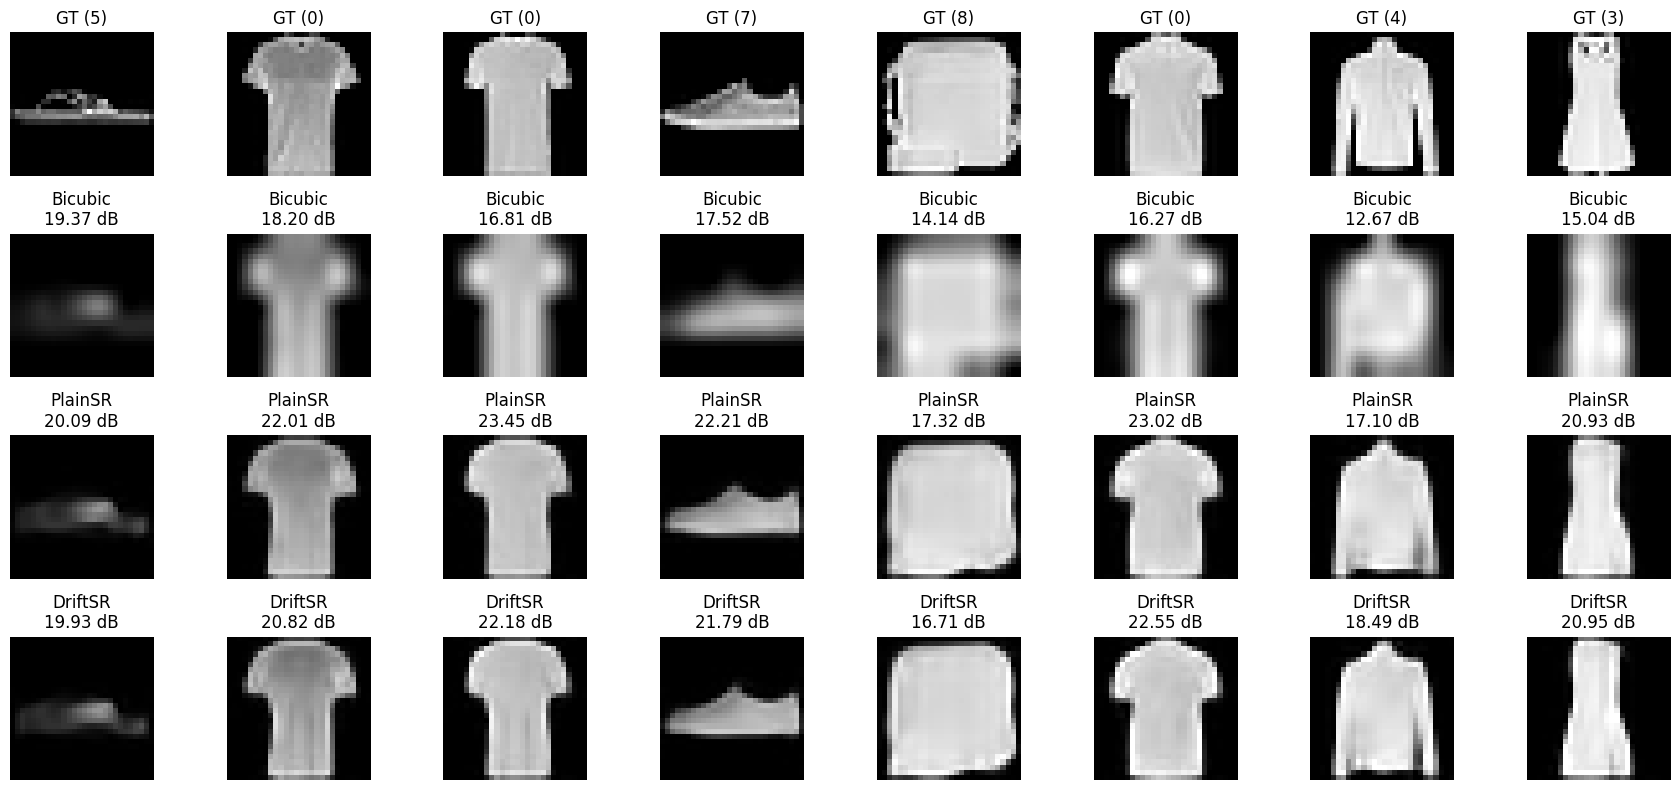

In [1]:
import math
import copy
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


@dataclass
class Config:
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 42

    data_root: str = "./data"
    batch_size: int = 128
    test_batch_size: int = 256
    num_workers: int = 0

    img_size: int = 28
    scale: int = 4

    # degradation
    blur_first: bool = True
    blur_kernel_size: int = 5
    blur_sigma: float = 1.0

    # model
    sr_base: int = 64
    sr_blocks: int = 6
    sr_res_scale: float = 0.2

    # encoder
    enc_base: int = 32
    enc_feat_dim: int = 256

    # encoder pretrain
    pretrain_encoder: bool = False
    pretrain_epochs: int = 3
    pretrain_lr: float = 1e-3

    # training
    epochs: int = 3
    lr: float = 2e-4
    weight_decay: float = 1e-4
    grad_clip: float = 1.0

    # schedule
    warmup_steps: int = 500
    drift_ramp_steps: int = 1000

    # drift
    lam_cond: float = 2.0
    temperatures: tuple = (0.05, 0.2, 0.8)
    beta_repel: float = 1.0
    drift_step: float = 0.20
    drift_target_variance: float = 1.0

    # losses
    lr_consistency_w_drift: float = 0.01
    recon_anchor_w_drift: float = 0.01
    lr_consistency_w: float = 0.5

    # logging / eval
    log_every: int = 100
    eval_batches: int = 20


cfg = Config()
torch.manual_seed(cfg.seed)
device = cfg.device


tfm = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.FashionMNIST(cfg.data_root, train=True, download=True, transform=tfm)
test_ds = datasets.FashionMNIST(cfg.data_root, train=False, download=True, transform=tfm)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=cfg.num_workers,
)
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.test_batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=cfg.num_workers,
)


def gaussian_kernel(size=5, sigma=1.0, channels=1, device="cpu"):
    coords = torch.arange(size, device=device) - size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma * sigma))
    g = g / g.sum()
    kernel2d = torch.outer(g, g)
    kernel2d = kernel2d / kernel2d.sum()
    kernel2d = kernel2d.view(1, 1, size, size).repeat(channels, 1, 1, 1)
    return kernel2d


def blur_image(x, kernel_size=5, sigma=1.0):
    c = x.shape[1]
    kernel = gaussian_kernel(kernel_size, sigma, channels=c, device=x.device)
    pad = kernel_size // 2
    return F.conv2d(x, kernel, padding=pad, groups=c)


def degrade_to_lr(
    x_hr,
    scale=4,
    blur_first=True,
    kernel_size=5,
    sigma=1.0,
):
    if blur_first:
        x_hr = blur_image(x_hr, kernel_size=kernel_size, sigma=sigma)
    h, w = x_hr.shape[-2:]
    lr = F.interpolate(
        x_hr,
        size=(h // scale, w // scale),
        mode="bicubic",
        align_corners=False,
    )
    return lr


def upsample_lr(lr, out_hw):
    return F.interpolate(lr, size=out_hw, mode="bicubic", align_corners=False)


def make_lr_up(x_hr, cfg: Config):
    lr = degrade_to_lr(
        x_hr,
        scale=cfg.scale,
        blur_first=cfg.blur_first,
        kernel_size=cfg.blur_kernel_size,
        sigma=cfg.blur_sigma,
    )
    y_up = upsample_lr(lr, x_hr.shape[-2:])
    return lr, y_up


class ResidualBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.SiLU(),
            nn.Conv2d(ch, ch, 3, padding=1),
        )

    def forward(self, x):
        return x + self.block(x)


class TinySRResidual(nn.Module):
    def __init__(self, in_ch=1, base=64, num_blocks=6, res_scale=0.2):
        super().__init__()
        self.res_scale = res_scale

        self.head = nn.Sequential(
            nn.Conv2d(in_ch, base, 3, padding=1),
            nn.SiLU(),
        )

        body = []
        for _ in range(num_blocks):
            body.append(ResidualBlock(base))
            body.append(nn.SiLU())
        self.body = nn.Sequential(*body)

        self.tail = nn.Conv2d(base, 1, 3, padding=1)

    def forward(self, y_up):
        feat = self.head(y_up)
        feat = self.body(feat)
        residual = self.res_scale * self.tail(feat)
        return y_up + residual


class BasicBlockGN(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.gn1 = nn.GroupNorm(min(16, out_ch), out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.gn2 = nn.GroupNorm(min(16, out_ch), out_ch)

        if stride != 1 or in_ch != out_ch:
            self.short = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.GroupNorm(min(16, out_ch), out_ch),
            )
        else:
            self.short = nn.Identity()

    def forward(self, x):
        h = F.gelu(self.gn1(self.conv1(x)))
        h = self.gn2(self.conv2(h))
        h = h + self.short(x)
        return F.gelu(h)


class MultiScaleFeatureEncoder(nn.Module):
    def __init__(self, in_channels=1, base_width=32, feature_dim=256):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, base_width, 3, padding=1, bias=False),
            nn.GroupNorm(min(16, base_width), base_width),
            nn.GELU(),
        )
        self.stage1 = nn.Sequential(
            BasicBlockGN(base_width, base_width, stride=1),
            BasicBlockGN(base_width, base_width, stride=1),
        )
        self.stage2 = nn.Sequential(
            BasicBlockGN(base_width, base_width * 2, stride=2),
            BasicBlockGN(base_width * 2, base_width * 2, stride=1),
        )
        self.stage3 = nn.Sequential(
            BasicBlockGN(base_width * 2, base_width * 4, stride=2),
            BasicBlockGN(base_width * 4, base_width * 4, stride=1),
        )
        self.stage4 = nn.Sequential(
            BasicBlockGN(base_width * 4, base_width * 8, stride=2),
            BasicBlockGN(base_width * 8, base_width * 8, stride=1),
        )
        total = base_width + base_width * 2 + base_width * 4 + base_width * 8
        self.proj = nn.Linear(total, feature_dim)

    def forward(self, x):
        x = self.stem(x)
        f1 = self.stage1(x)
        f2 = self.stage2(f1)
        f3 = self.stage3(f2)
        f4 = self.stage4(f3)

        p1 = F.adaptive_avg_pool2d(f1, 1).flatten(1)
        p2 = F.adaptive_avg_pool2d(f2, 1).flatten(1)
        p3 = F.adaptive_avg_pool2d(f3, 1).flatten(1)
        p4 = F.adaptive_avg_pool2d(f4, 1).flatten(1)

        feat = torch.cat([p1, p2, p3, p4], dim=1)
        feat = self.proj(feat)
        return feat

class EncoderPretrainRecon(nn.Module):
    def __init__(self, encoder: MultiScaleFeatureEncoder, feature_dim=256):
        super().__init__()
        self.encoder = encoder
        self.decoder = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Linear(512, 28 * 28),
        )

    def forward(self, x_in):
        feat = self.encoder(x_in)
        out = self.decoder(feat).view(-1, 1, 28, 28)
        return out


def pretrain_feature_encoder(feature_encoder, train_loader, cfg: Config):
    pre_model = EncoderPretrainRecon(feature_encoder, feature_dim=cfg.enc_feat_dim).to(cfg.device)
    opt = torch.optim.AdamW(pre_model.parameters(), lr=cfg.pretrain_lr, weight_decay=1e-4)

    pre_model.train()
    for ep in range(1, cfg.pretrain_epochs + 1):
        losses = []
        for x_hr, _ in train_loader:
            x_hr = x_hr.to(cfg.device)
            _, y_up = make_lr_up(x_hr, cfg)

            pred = pre_model(y_up)
            loss = F.l1_loss(pred, x_hr)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            losses.append(loss.item())

        print(f"[encoder pretrain] epoch {ep}: loss={sum(losses)/len(losses):.6f}")

    return pre_model.encoder


@torch.no_grad()
def normalize_features_batch(features, mean=None, std=None, scale=None):
    D = features.shape[1]
    target_dist = D ** 0.5

    if mean is None:
        mean = features.mean(dim=0, keepdim=True)
    if std is None:
        std = features.std(dim=0, keepdim=True) + 1e-8

    z = (features - mean) / std

    if scale is None:
        n_sample = min(features.shape[0], 256)
        idx = torch.randperm(features.shape[0], device=features.device)[:n_sample]
        subset = z[idx]
        d = torch.cdist(subset, subset, p=2)
        mask = ~torch.eye(n_sample, device=features.device, dtype=torch.bool)
        avg_dist = d[mask].mean()
        scale = (target_dist / (avg_dist + 1e-8)).item()

    return z * scale, mean, std, scale


@torch.no_grad()
def normalize_drift(V, target_variance=1.0):
    cur = torch.mean(V ** 2)
    scale = (target_variance / (cur + 1e-8)) ** 0.5
    return V * scale



@torch.no_grad()
def compute_affinity_paper(
    x_feat,
    y_pos_feat,
    y_neg_feat,
    temperature,
    mask_self=True,
):
    N = x_feat.shape[0]
    N_pos = y_pos_feat.shape[0]
    N_neg = y_neg_feat.shape[0]

    dist_pos = torch.cdist(x_feat, y_pos_feat, p=2)
    dist_neg = torch.cdist(x_feat, y_neg_feat, p=2)

    if mask_self and N == N_neg:
        dist_neg = dist_neg + torch.eye(N, device=x_feat.device) * 1e6

    logit_pos = -dist_pos / temperature
    logit_neg = -dist_neg / temperature
    logit = torch.cat([logit_pos, logit_neg], dim=1)

    A_row = torch.softmax(logit, dim=1)
    A_col = torch.softmax(logit, dim=0)
    A = torch.sqrt(A_row * A_col + 1e-12)

    A_pos = A[:, :N_pos]
    A_neg = A[:, N_pos:]

    W_pos = A_pos * A_neg.sum(dim=1, keepdim=True)
    W_neg = A_neg * A_pos.sum(dim=1, keepdim=True)
    return W_pos, W_neg


@torch.no_grad()
def compute_conditional_drift_sr(
    gen_img,
    pos_img,
    cond_up,
    cond_lr,
    feature_encoder,
    lam_cond=2.0,
    temperatures=(0.05, 0.2, 0.8),
    beta_repel=0.25,
    drift_target_variance=1.0,
):
    r_gen_img = gen_img - cond_up
    r_pos_img = pos_img - cond_up

    f_r_gen = feature_encoder(r_gen_img)
    f_r_pos = feature_encoder(r_pos_img)
    f_cond = feature_encoder(cond_lr)

    f_r_gen, mean_rg, std_rg, scale_rg = normalize_features_batch(f_r_gen)
    f_r_pos, _, _, _ = normalize_features_batch(f_r_pos, mean_rg, std_rg, scale_rg)
    f_cond, _, _, _ = normalize_features_batch(f_cond)

    joint_gen = torch.cat([f_r_gen, lam_cond * f_cond], dim=1)
    joint_pos = torch.cat([f_r_pos, lam_cond * f_cond], dim=1)
    joint_neg = joint_gen

    rg = r_gen_img.flatten(1)
    rp = r_pos_img.flatten(1)

    V_total = torch.zeros_like(rg)

    for tau in temperatures:
        W_pos, W_neg = compute_affinity_paper(
            joint_gen, joint_pos, joint_neg, temperature=tau, mask_self=True
        )

        drift_pos = torch.mm(W_pos, rp)
        drift_neg = torch.mm(W_neg, rg)
        V_tau = drift_pos - beta_repel * drift_neg

        V_tau = normalize_drift(V_tau, target_variance=1.0)
        V_total = V_total + V_tau

    V_total = normalize_drift(V_total, target_variance=drift_target_variance)
    return V_total.view_as(gen_img)


def drift_sr_loss(
    gen_img,
    pos_img,
    cond_up,
    cond_lr,
    feature_encoder,
    cfg: Config,
):
    with torch.no_grad():
        V = compute_conditional_drift_sr(
            gen_img=gen_img,
            pos_img=pos_img,
            cond_up=cond_up,
            cond_lr=cond_lr,
            feature_encoder=feature_encoder,
            lam_cond=cfg.lam_cond,
            temperatures=cfg.temperatures,
            beta_repel=cfg.beta_repel,
            drift_target_variance=cfg.drift_target_variance,
        )
        target = (gen_img + cfg.drift_step * V).detach()

    loss_drift = F.smooth_l1_loss(gen_img, target)

    lr_pred = degrade_to_lr(
        gen_img,
        scale=cfg.scale,
        blur_first=cfg.blur_first,
        kernel_size=cfg.blur_kernel_size,
        sigma=cfg.blur_sigma,
    )
    loss_lr = F.l1_loss(lr_pred, cond_lr)
    loss_recon = F.l1_loss(gen_img, pos_img)

    total = (
        loss_drift
        + cfg.lr_consistency_w_drift * loss_lr
        + cfg.recon_anchor_w_drift * loss_recon
    )

    info = {
        "loss_drift": loss_drift.item(),
        "loss_lr": loss_lr.item(),
        "loss_recon": loss_recon.item(),
        "V_rms": torch.mean(V ** 2).sqrt().item(),
    }
    return total, info


def train_plain_sr(
    model,
    train_loader,
    test_loader,
    cfg: Config,
):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    loss_history = []
    psnr_history = []
    bicubic_psnr_history = []

    model.train()

    for ep in range(1, cfg.epochs + 1):
        running = []

        for global_step, (x_hr, _) in enumerate(train_loader):
            x_hr = x_hr.to(cfg.device)
            lr, y_up = make_lr_up(x_hr, cfg)
            lr = lr.to(cfg.device)
            y_up = y_up.to(cfg.device)

            x_hat = model(y_up)

            loss = (
                F.l1_loss(x_hat, x_hr)
                + cfg.lr_consistency_w * F.l1_loss(
                    degrade_to_lr(
                        x_hat,
                        scale=cfg.scale,
                        blur_first=cfg.blur_first,
                        kernel_size=cfg.blur_kernel_size,
                        sigma=cfg.blur_sigma,
                    ),
                    lr,
                )
            )

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            if cfg.grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()

            running.append(loss.item())
            loss_history.append(loss.item())

            if global_step % cfg.log_every == 0:
                print(f"[plain] ep {ep} step {global_step}: loss={loss.item():.6f}")

        mean_loss = sum(running) / len(running)
        stats = eval_psnr(model, test_loader, cfg, num_batches=cfg.eval_batches)
        psnr_history.append(stats["psnr_model"])
        bicubic_psnr_history.append(stats["psnr_bicubic"])

        print(
            f"[plain] epoch {ep} | mean_loss={mean_loss:.6f} | "
            f"test_psnr={stats['psnr_model']:.3f} dB | "
            f"bicubic={stats['psnr_bicubic']:.3f} dB"
        )

    return loss_history, psnr_history, bicubic_psnr_history


def train_drifting_sr(
    model,
    feature_encoder,
    train_loader,
    test_loader,
    cfg: Config,
):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    loss_history = []
    psnr_history = []
    bicubic_psnr_history = []

    feature_encoder.eval()
    for p in feature_encoder.parameters():
        p.requires_grad = False

    model.train()
    global_step = 0

    for ep in range(1, cfg.epochs + 1):
        running = []

        for x_hr, _ in train_loader:
            x_hr = x_hr.to(cfg.device)
            lr, y_up = make_lr_up(x_hr, cfg)
            lr = lr.to(cfg.device)
            y_up = y_up.to(cfg.device)

            x_hat = model(y_up)

            if global_step < cfg.warmup_steps:
                loss = (
                    F.l1_loss(x_hat, x_hr)
                    + cfg.lr_consistency_w * F.l1_loss(
                        degrade_to_lr(
                            x_hat,
                            scale=cfg.scale,
                            blur_first=cfg.blur_first,
                            kernel_size=cfg.blur_kernel_size,
                            sigma=cfg.blur_sigma,
                        ),
                        lr,
                    )
                )
                info = {"mode": "warmup"}
            else:
                drift_w = min(
                    1.0,
                    (global_step - cfg.warmup_steps + 1) / max(1, cfg.drift_ramp_steps),
                )

                loss_drift, info_d = drift_sr_loss(
                    gen_img=x_hat,
                    pos_img=x_hr,
                    cond_up=y_up,
                    cond_lr=lr,
                    feature_encoder=feature_encoder,
                    cfg=cfg,
                )

                loss_plain = (
                    F.l1_loss(x_hat, x_hr)
                    + cfg.lr_consistency_w * F.l1_loss(
                        degrade_to_lr(
                            x_hat,
                            scale=cfg.scale,
                            blur_first=cfg.blur_first,
                            kernel_size=cfg.blur_kernel_size,
                            sigma=cfg.blur_sigma,
                        ),
                        lr,
                    )
                )

                loss = (1.0 - drift_w) * loss_plain + drift_w * loss_drift
                info = {"mode": "drift", "drift_w": drift_w, **info_d}

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            if cfg.grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()

            running.append(loss.item())
            loss_history.append(loss.item())

            if global_step % cfg.log_every == 0:
                msg = f"[drift] ep {ep} step {global_step}: loss={loss.item():.6f}"
                if info["mode"] == "drift":
                    msg += (
                        f" | drift_w={info['drift_w']:.3f}"
                        f" | drift={info['loss_drift']:.5f}"
                        f" | lr={info['loss_lr']:.5f}"
                        f" | recon={info['loss_recon']:.5f}"
                        f" | V_rms={info['V_rms']:.5f}"
                    )
                else:
                    msg += " | warmup"
                print(msg)

            global_step += 1

        mean_loss = sum(running) / len(running)
        stats = eval_psnr(model, test_loader, cfg, num_batches=cfg.eval_batches)
        psnr_history.append(stats["psnr_model"])
        bicubic_psnr_history.append(stats["psnr_bicubic"])

        print(
            f"[drift] epoch {ep} | mean_loss={mean_loss:.6f} | "
            f"test_psnr={stats['psnr_model']:.3f} dB | "
            f"bicubic={stats['psnr_bicubic']:.3f} dB"
        )

    return loss_history, psnr_history, bicubic_psnr_history


@torch.no_grad()
def eval_psnr(model, loader, cfg: Config, num_batches=20):
    model.eval()
    psnrs_model = []
    psnrs_bic = []

    for i, (x_hr, _) in enumerate(loader):
        if i >= num_batches:
            break

        x_hr = x_hr.to(cfg.device)
        _, y_up = make_lr_up(x_hr, cfg)
        y_up = y_up.to(cfg.device)

        x_hat = model(y_up).clamp(0, 1)

        mse_model = F.mse_loss(x_hat, x_hr)
        mse_bic = F.mse_loss(y_up, x_hr)

        psnrs_model.append((-10.0 * torch.log10(mse_model + 1e-12)).item())
        psnrs_bic.append((-10.0 * torch.log10(mse_bic + 1e-12)).item())

    model.train()
    return {
        "psnr_model": sum(psnrs_model) / max(1, len(psnrs_model)),
        "psnr_bicubic": sum(psnrs_bic) / max(1, len(psnrs_bic)),
    }


@torch.no_grad()
def show_comparison_results(model_plain, model_drift, loader, cfg: Config, num_images=8, seed=1):
    model_plain.eval()
    model_drift.eval()

    x_hr, labels = next(iter(loader))
    x_hr = x_hr.to(cfg.device)

    _, y_up = make_lr_up(x_hr, cfg)
    y_up = y_up.to(cfg.device)

    x_hat_plain = model_plain(y_up).clamp(0, 1)
    x_hat_drift = model_drift(y_up).clamp(0, 1)

    B = x_hr.shape[0]
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(B, generator=g)[:num_images]

    x_hr_s = x_hr[idx].cpu()
    y_up_s = y_up[idx].cpu()
    x_hat_plain_s = x_hat_plain[idx].cpu()
    x_hat_drift_s = x_hat_drift[idx].cpu()
    lab_s = labels[idx].cpu()

    psnrs_bic, psnrs_plain, psnrs_drift = [], [], []
    for i in range(num_images):
        mse_b = F.mse_loss(y_up_s[i], x_hr_s[i])
        mse_p = F.mse_loss(x_hat_plain_s[i], x_hr_s[i])
        mse_d = F.mse_loss(x_hat_drift_s[i], x_hr_s[i])

        psnrs_bic.append((-10.0 * torch.log10(mse_b + 1e-12)).item())
        psnrs_plain.append((-10.0 * torch.log10(mse_p + 1e-12)).item())
        psnrs_drift.append((-10.0 * torch.log10(mse_d + 1e-12)).item())

    fig, axes = plt.subplots(4, num_images, figsize=(2.2 * num_images, 8))
    for j in range(num_images):
        axes[0, j].imshow(x_hr_s[j, 0], cmap="gray", vmin=0, vmax=1)
        axes[0, j].set_title(f"GT ({lab_s[j].item()})")
        axes[0, j].axis("off")

        axes[1, j].imshow(y_up_s[j, 0], cmap="gray", vmin=0, vmax=1)
        axes[1, j].set_title(f"Bicubic\n{psnrs_bic[j]:.2f} dB")
        axes[1, j].axis("off")

        axes[2, j].imshow(x_hat_plain_s[j, 0], cmap="gray", vmin=0, vmax=1)
        axes[2, j].set_title(f"PlainSR\n{psnrs_plain[j]:.2f} dB")
        axes[2, j].axis("off")

        axes[3, j].imshow(x_hat_drift_s[j, 0], cmap="gray", vmin=0, vmax=1)
        axes[3, j].set_title(f"DriftSR\n{psnrs_drift[j]:.2f} dB")
        axes[3, j].axis("off")

    plt.tight_layout()
    plt.show()

    model_plain.train()
    model_drift.train()


def plot_comparison_curves(
    plain_loss_history,
    plain_psnr_history,
    drift_loss_history,
    drift_psnr_history,
    bicubic_psnr_history,
):
    plt.figure(figsize=(8, 4))
    plt.plot(plain_loss_history, label="Plain SR loss")
    plt.plot(drift_loss_history, label="Drift SR loss")
    plt.title("Training Loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    epochs = list(range(1, len(plain_psnr_history) + 1))
    plt.plot(epochs, plain_psnr_history, marker="o", label="Plain SR test PSNR")
    plt.plot(epochs, drift_psnr_history, marker="o", label="Drift SR test PSNR")
    plt.plot(epochs, bicubic_psnr_history, marker="o", label="Bicubic PSNR")
    plt.title("Test PSNR per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("PSNR (dB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def main():
    print("Device:", cfg.device)

    model_plain = TinySRResidual(
        in_ch=1,
        base=cfg.sr_base,
        num_blocks=cfg.sr_blocks,
        res_scale=cfg.sr_res_scale,
    ).to(cfg.device)

    model_drift = TinySRResidual(
        in_ch=1,
        base=cfg.sr_base,
        num_blocks=cfg.sr_blocks,
        res_scale=cfg.sr_res_scale,
    ).to(cfg.device)

    feature_encoder = MultiScaleFeatureEncoder(
        in_channels=1,
        base_width=cfg.enc_base,
        feature_dim=cfg.enc_feat_dim,
    ).to(cfg.device)

    if cfg.pretrain_encoder:
        feature_encoder = pretrain_feature_encoder(feature_encoder, train_loader, cfg)

    feature_encoder = copy.deepcopy(feature_encoder).eval().to(cfg.device)
    for p in feature_encoder.parameters():
        p.requires_grad = False

    print("Start plain SR training...")
    plain_loss_history, plain_psnr_history, plain_bicubic_psnr_history = train_plain_sr(
        model_plain,
        train_loader,
        test_loader,
        cfg,
    )

    print("Start drifting SR training...")
    drift_loss_history, drift_psnr_history, drift_bicubic_psnr_history = train_drifting_sr(
        model_drift,
        feature_encoder,
        train_loader,
        test_loader,
        cfg,
    )

    stats_plain = eval_psnr(model_plain, test_loader, cfg, num_batches=cfg.eval_batches)
    stats_drift = eval_psnr(model_drift, test_loader, cfg, num_batches=cfg.eval_batches)

    print(
        f"Final Test PSNR | plain: {stats_plain['psnr_model']:.3f} dB | "
        f"drift: {stats_drift['psnr_model']:.3f} dB | "
        f"bicubic: {stats_drift['psnr_bicubic']:.3f} dB"
    )

    plot_comparison_curves(
        plain_loss_history,
        plain_psnr_history,
        drift_loss_history,
        drift_psnr_history,
        drift_bicubic_psnr_history,
    )

    show_comparison_results(
        model_plain,
        model_drift,
        test_loader,
        cfg,
        num_images=8,
        seed=1,
    )


if __name__ == "__main__":
    main()